In [1]:
# ------------------------------------------------------------
# 1. Carga de Datos y Librerías
# ------------------------------------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as mostrar

# Configuración de visualización de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")

# Rutas a los datasets procesados
processed_dir = "../Data/processed"

print("Cargando conjuntos de datos procesados...")
X_train_bal = pd.read_csv(os.path.join(processed_dir, "X_train_bal.csv"))
y_train_bal = pd.read_csv(os.path.join(processed_dir, "y_train_bal.csv"))["discoverymethod"]
X_test = pd.read_csv(os.path.join(processed_dir, "X_test.csv"))
y_test = pd.read_csv(os.path.join(processed_dir, "y_test.csv"))["discoverymethod"]

print(f"Train: X_train_bal shape = {X_train_bal.shape} | y_train_bal shape = {y_train_bal.shape}")
print(f"Test:  X_test shape = {X_test.shape} | y_test shape = {y_test.shape}")


Cargando conjuntos de datos procesados...
Train: X_train_bal shape = (11591, 32) | y_train_bal shape = (11591,)
Test:  X_test shape = (1152, 32) | y_test shape = (1152,)


In [2]:
# ============================================================
# 15. Modelado y Extracción de Patrones (Sprint 3)
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Definición de Algoritmos y Parámetros
# ------------------------------------------------------------
# Random Forest: Robusto frente a varianza, excelente para datasets con muchas features
rf_params = {
    'n_estimators': 150,     # Cantidad de árboles en el bosque
    'max_depth': 12,         # Profundidad máxima para evitar overfitting
    'min_samples_split': 5,  # Mínimo de muestras para dividir un nodo
    'random_state': 42,
    'class_weight': 'balanced' # Compensación extra por si SMOTEENN dejó leves desbalances
}
rf_model = RandomForestClassifier(**rf_params)

# Gradient Boosting: Algoritmo secuencial, optimiza los errores del árbol anterior
gb_params = {
    'n_estimators': 150,
    'learning_rate': 0.1,    # Tasa de aprendizaje (qué tanto corrige cada árbol)
    'max_depth': 5,          # Profundidad menor que RF porque tiende más al overfitting
    'random_state': 42
}
gb_model = GradientBoostingClassifier(**gb_params)

print("Entrenando Random Forest...")
rf_model.fit(X_train_bal, y_train_bal)

print("Entrenando Gradient Boosting...")
gb_model.fit(X_train_bal, y_train_bal)
print("Entrenamiento completado.\n")

# 2. Evaluación en el Test Set (Distribución Real)
# ------------------------------------------------------------
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

print("="*60)
print("REPORTE DE CLASIFICACIÓN - RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf))

print("="*60)
print("REPORTE DE CLASIFICACIÓN - GRADIENT BOOSTING")
print("="*60)
print(classification_report(y_test, y_pred_gb))

Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenamiento completado.

REPORTE DE CLASIFICACIÓN - RANDOM FOREST
                 precision    recall  f1-score   support

   Microlensing       0.98      1.00      0.99        46
         Others       0.71      0.93      0.81        29
Radial Velocity       0.94      0.95      0.95       216
        Transit       1.00      0.98      0.99       861

       accuracy                           0.98      1152
      macro avg       0.91      0.97      0.93      1152
   weighted avg       0.98      0.98      0.98      1152

REPORTE DE CLASIFICACIÓN - GRADIENT BOOSTING
                 precision    recall  f1-score   support

   Microlensing       0.96      1.00      0.98        46
         Others       0.71      0.86      0.78        29
Radial Velocity       0.97      0.98      0.97       216
        Transit       1.00      0.99      0.99       861

       accuracy                           0.98      1152
      macro avg       0.

In [3]:
# ============================================================
# 16. Modelo Base: Regresión Logística Multinomial
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# La Regresión Logística es sensible a la escala de las variables.
# El scaler se ajusta SOLO con train para evitar data leakage.
scaler_lr = StandardScaler()
X_train_bal_scaled = scaler_lr.fit_transform(X_train_bal)
X_test_scaled = scaler_lr.transform(X_test)

lr_params = {
    'C': 1.0,                 # Inverso de la regularización
    'max_iter': 3000,
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    'random_state': 42
}
lr_model = LogisticRegression(**lr_params)

print("Entrenando Regresión Logística Multinomial...")
lr_model.fit(X_train_bal_scaled, y_train_bal)
y_pred_lr = lr_model.predict(X_test_scaled)

print("="*60)
print("REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA")
print("="*60)
print(classification_report(y_test, y_pred_lr))


Entrenando Regresión Logística Multinomial...
REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA
                 precision    recall  f1-score   support

   Microlensing       1.00      1.00      1.00        46
         Others       0.35      0.86      0.50        29
Radial Velocity       0.92      0.91      0.92       216
        Transit       1.00      0.95      0.97       861

       accuracy                           0.94      1152
      macro avg       0.82      0.93      0.85      1152
   weighted avg       0.97      0.94      0.95      1152



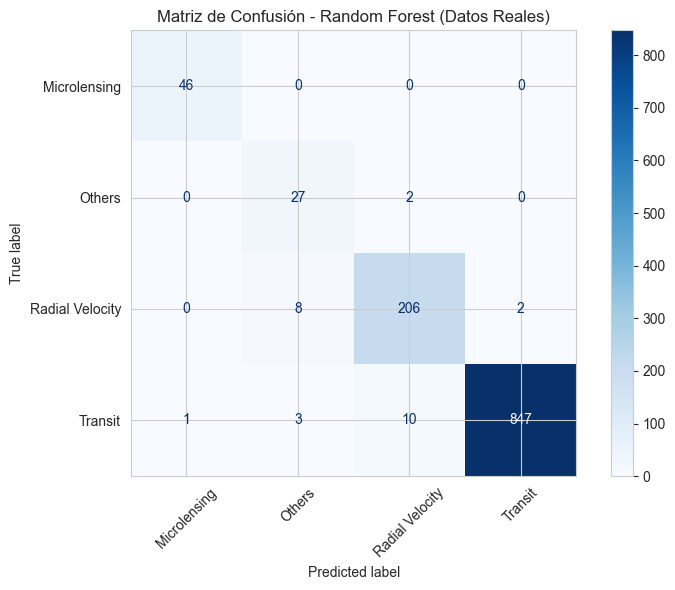

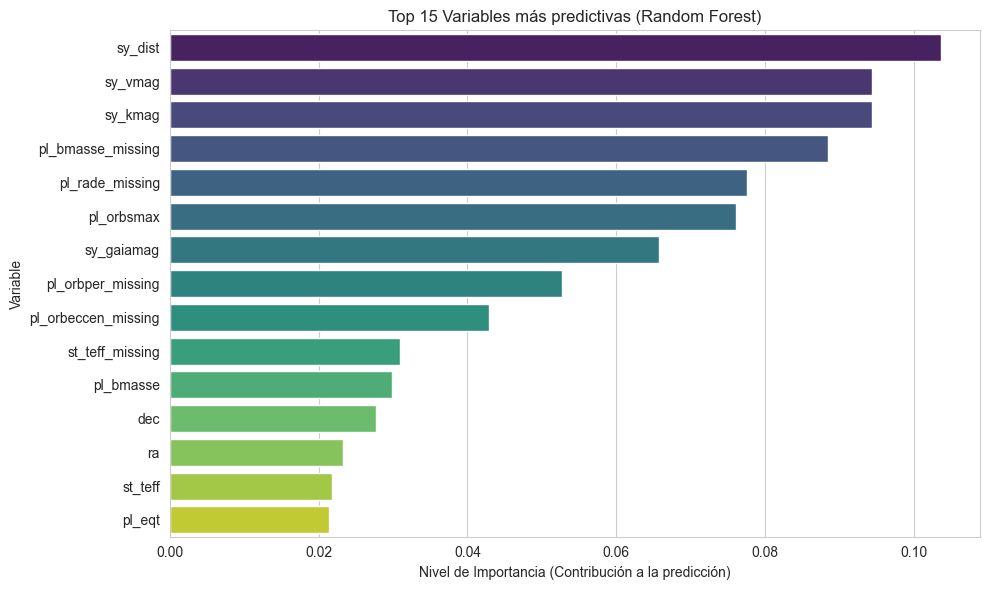

In [4]:
# ============================================================
# 17. Interpretación de Resultados
# ============================================================

# 1. Matriz de Confusión (Random Forest como modelo principal)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest (Datos Reales)")
plt.tight_layout()
plt.show()

# 2. Importancia de Variables (Feature Importance)
# Esto nos dice QUÉ reglas físicas aprendió el modelo
importances = rf_model.feature_importances_
features = X_train_bal.columns
feat_imp = pd.DataFrame({'Variable': features, 'Importancia': importances})
feat_imp = feat_imp.sort_values('Importancia', ascending=False).head(15) # Top 15

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feat_imp, hue='Variable', palette='viridis', legend=False)
plt.title("Top 15 Variables más predictivas (Random Forest)")
plt.xlabel("Nivel de Importancia (Contribución a la predicción)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


COMPARACIÓN DE MODELOS


,Modelo,Accuracy Train,Accuracy Test,F1 Macro Test,F1 Ponderado Test,Precision Ponderada Test,Recall Ponderado Test
0,Random Forest,0.9984,0.9774,0.9338,0.9782,0.9798,0.9774
1,Gradient Boosting,1.0000,0.9826,0.9313,0.9832,0.9842,0.9826
2,Regresión Logística,0.9670,0.9436,0.8475,0.9522,0.9670,0.9436



ANÁLISIS DE OVERFITTING (Diferencia Train-Test)
Random Forest: 0.0209 - Generalización aceptable
Gradient Boosting: 0.0174 - Generalización aceptable
Regresión Logística: 0.0235 - Generalización aceptable


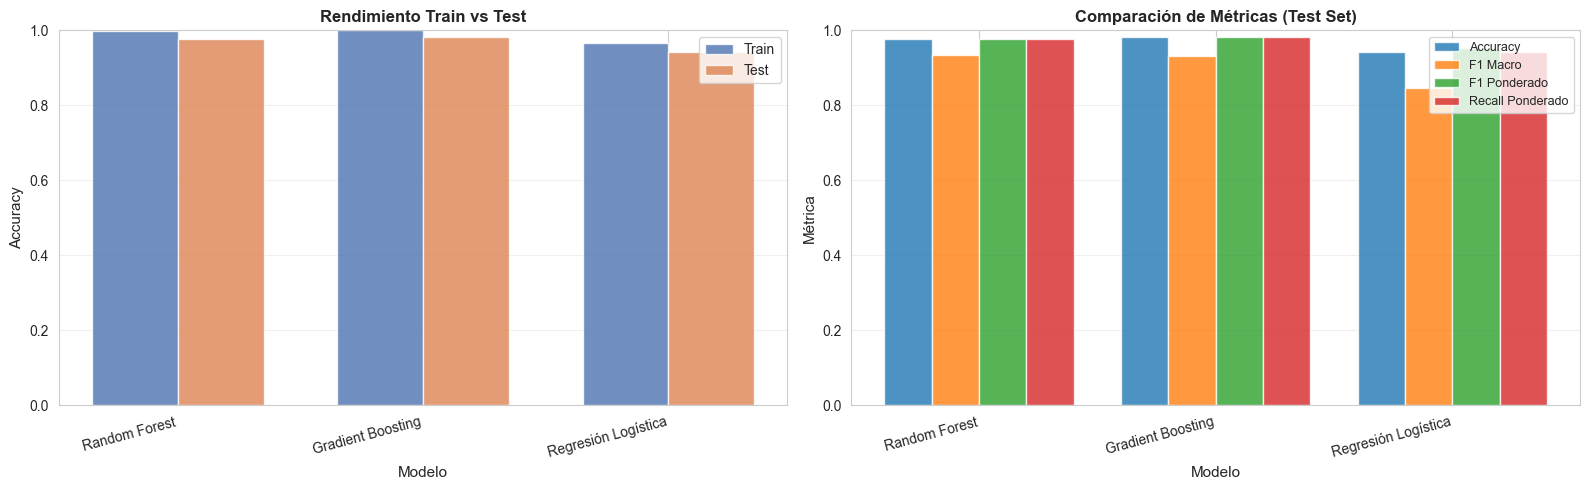


MEJOR MODELO (según F1 Macro): Random Forest (0.9338)


In [5]:
# ============================================================
# 18. Comparación de Modelos y Análisis de Overfitting
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

modelos = ['Random Forest', 'Gradient Boosting', 'Regresión Logística']
predicciones_test = [y_pred_rf, y_pred_gb, y_pred_lr]
predicciones_train = [
    rf_model.predict(X_train_bal),
    gb_model.predict(X_train_bal),
    lr_model.predict(X_train_bal_scaled)
]

# F1 macro da el mismo peso a cada clase; F1 ponderado considera su cantidad de casos.
metricas = {
    'Modelo': modelos,
    'Accuracy Train': [
        accuracy_score(y_train_bal, pred) for pred in predicciones_train
    ],
    'Accuracy Test': [
        accuracy_score(y_test, pred) for pred in predicciones_test
    ],
    'F1 Macro Test': [
        f1_score(y_test, pred, average='macro') for pred in predicciones_test
    ],
    'F1 Ponderado Test': [
        f1_score(y_test, pred, average='weighted') for pred in predicciones_test
    ],
    'Precision Ponderada Test': [
        precision_score(y_test, pred, average='weighted') for pred in predicciones_test
    ],
    'Recall Ponderado Test': [
        recall_score(y_test, pred, average='weighted') for pred in predicciones_test
    ]
}

df_metricas = pd.DataFrame(metricas)
print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80)
mostrar(df_metricas)

# Análisis de Overfitting
print("\n" + "="*80)
print("ANÁLISIS DE OVERFITTING (Diferencia Train-Test)")
print("="*80)
for idx, modelo in enumerate(metricas['Modelo']):
    diff = metricas['Accuracy Train'][idx] - metricas['Accuracy Test'][idx]
    estado = "Overfitting detectado" if diff > 0.15 else "Generalización aceptable"
    print(f"{modelo}: {diff:.4f} - {estado}")

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Accuracy Train vs Test
x = np.arange(len(metricas['Modelo']))
width = 0.35
axes[0].bar(x - width/2, metricas['Accuracy Train'], width, label='Train', alpha=0.8, color='#4C72B0')
axes[0].bar(x + width/2, metricas['Accuracy Test'], width, label='Test', alpha=0.8, color='#DD8452')
axes[0].set_xlabel('Modelo', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Rendimiento Train vs Test', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas['Modelo'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Gráfico 2: Comparación de métricas en Test
width = 0.2
axes[1].bar(x - 1.5*width, metricas['Accuracy Test'], width, label='Accuracy', alpha=0.8)
axes[1].bar(x - 0.5*width, metricas['F1 Macro Test'], width, label='F1 Macro', alpha=0.8)
axes[1].bar(x + 0.5*width, metricas['F1 Ponderado Test'], width, label='F1 Ponderado', alpha=0.8)
axes[1].bar(x + 1.5*width, metricas['Recall Ponderado Test'], width, label='Recall Ponderado', alpha=0.8)
axes[1].set_xlabel('Modelo', fontsize=11)
axes[1].set_ylabel('Métrica', fontsize=11)
axes[1].set_title('Comparación de Métricas (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas['Modelo'], rotation=15, ha='right')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Se prioriza F1 macro porque el dataset original está desbalanceado.
mejor_idx = np.argmax(metricas['F1 Macro Test'])
mejor_modelo_nombre = metricas['Modelo'][mejor_idx]
mejor_f1_macro = metricas['F1 Macro Test'][mejor_idx]
mejor_f1_ponderado = metricas['F1 Ponderado Test'][mejor_idx]

print(f"\nMEJOR MODELO (según F1 Macro): {mejor_modelo_nombre} ({mejor_f1_macro:.4f})")


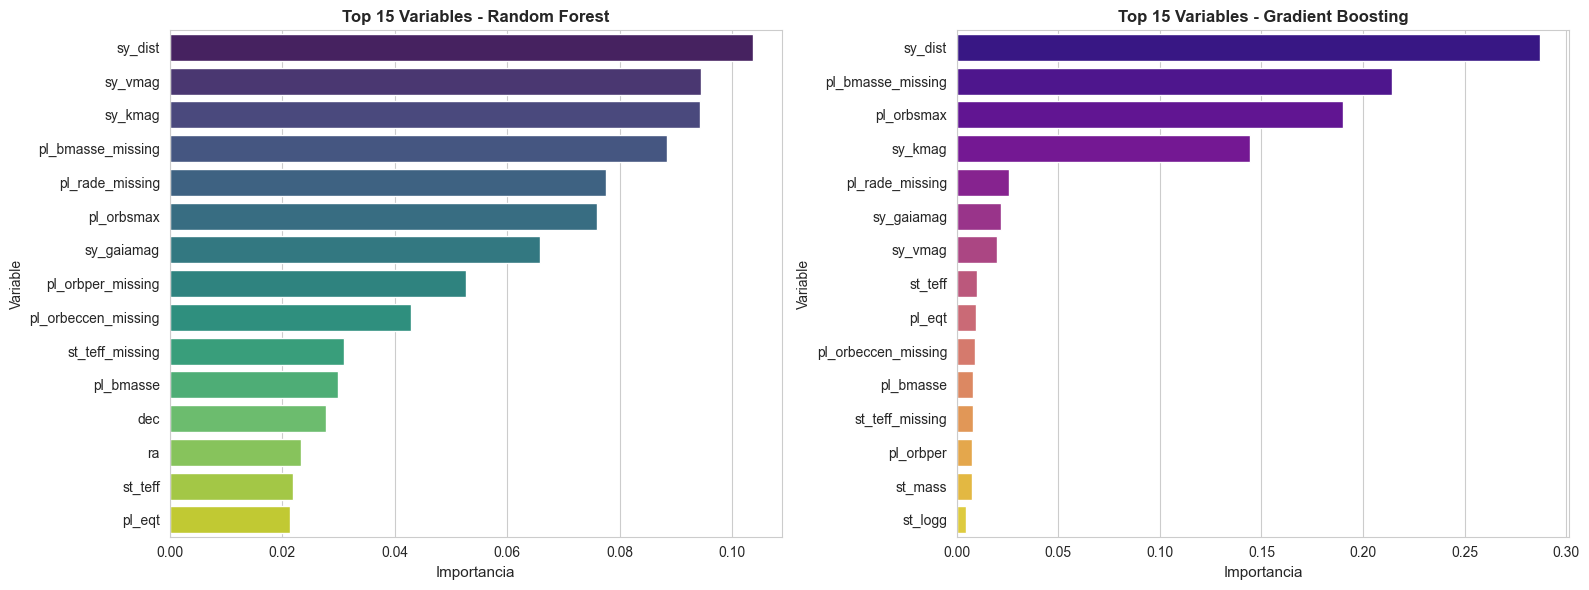

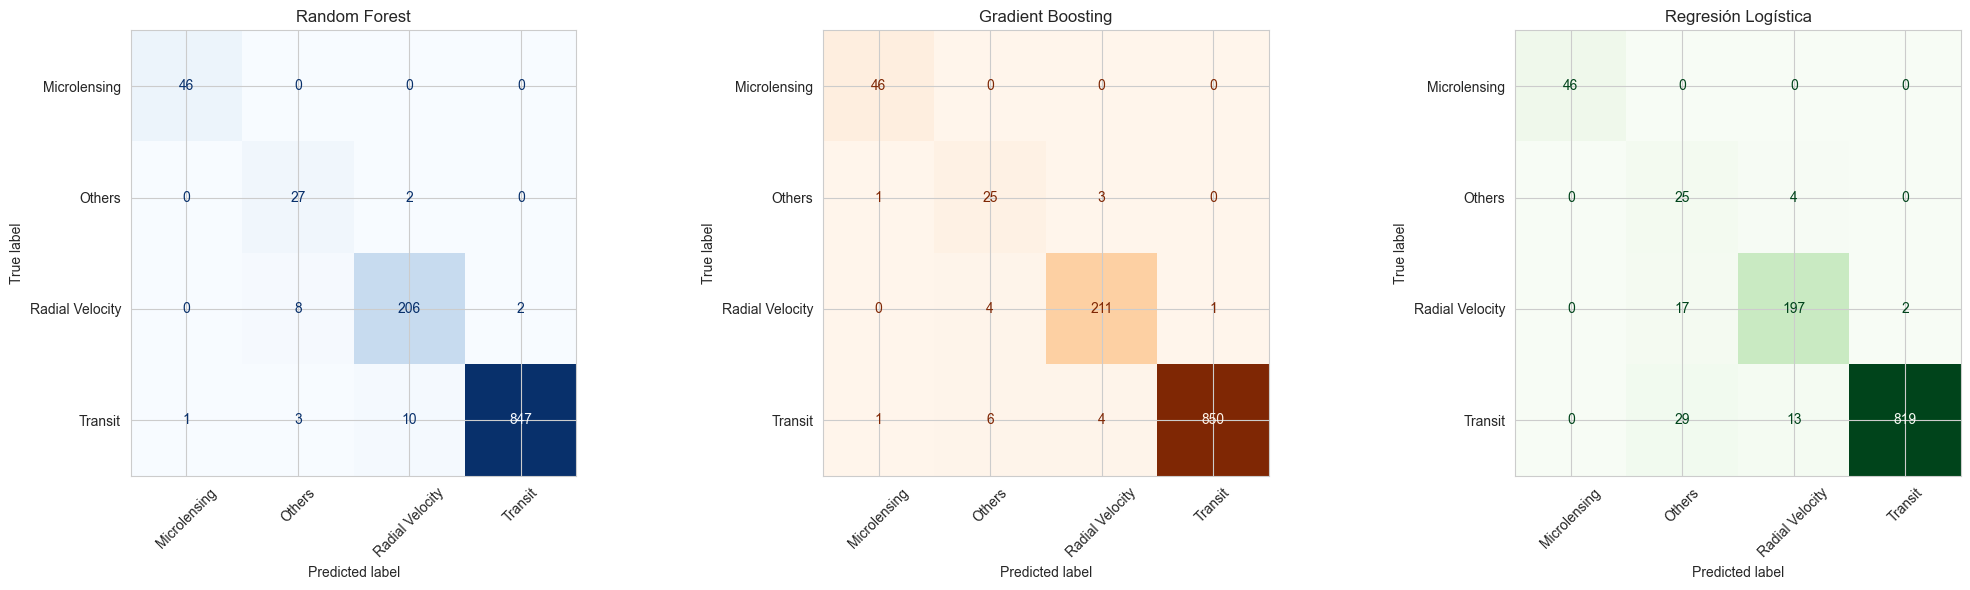


ANÁLISIS POR MÉTODO DE DESCUBRIMIENTO

RANDOM FOREST:
                 precision    recall  f1-score   support

   Microlensing     0.9787    1.0000    0.9892        46
         Others     0.7105    0.9310    0.8060        29
Radial Velocity     0.9450    0.9537    0.9493       216
        Transit     0.9976    0.9837    0.9906       861

       accuracy                         0.9774      1152
      macro avg     0.9080    0.9671    0.9338      1152
   weighted avg     0.9798    0.9774    0.9782      1152


GRADIENT BOOSTING:
                 precision    recall  f1-score   support

   Microlensing     0.9583    1.0000    0.9787        46
         Others     0.7143    0.8621    0.7812        29
Radial Velocity     0.9679    0.9769    0.9724       216
        Transit     0.9988    0.9872    0.9930       861

       accuracy                         0.9826      1152
      macro avg     0.9098    0.9565    0.9313      1152
   weighted avg     0.9842    0.9826    0.9832      1152


REGRES

In [6]:
# ============================================================
# 19. Interpretación Comparativa y Análisis por Clase
# ============================================================

# 1. Feature Importance para Gradient Boosting
gb_importances = gb_model.feature_importances_
gb_feat_imp = pd.DataFrame({'Variable': features, 'Importancia': gb_importances})
gb_feat_imp = gb_feat_imp.sort_values('Importancia', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Importancia', y='Variable', data=feat_imp, hue='Variable',
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Top 15 Variables - Random Forest", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Importancia", fontsize=11)

sns.barplot(x='Importancia', y='Variable', data=gb_feat_imp, hue='Variable',
            palette='plasma', legend=False, ax=axes[1])
axes[1].set_title("Top 15 Variables - Gradient Boosting", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Importancia", fontsize=11)

plt.tight_layout()
plt.show()

# 2. Matrices de confusión de los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
matrices = [
    ('Random Forest', y_pred_rf, rf_model.classes_, 'Blues'),
    ('Gradient Boosting', y_pred_gb, gb_model.classes_, 'Oranges'),
    ('Regresión Logística', y_pred_lr, lr_model.classes_, 'Greens')
]

for ax, (nombre, pred, clases, cmap) in zip(axes, matrices):
    cm_modelo = confusion_matrix(y_test, pred, labels=clases)
    disp_modelo = ConfusionMatrixDisplay(confusion_matrix=cm_modelo, display_labels=clases)
    disp_modelo.plot(cmap=cmap, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

# 3. Análisis por clase
print("\n" + "="*80)
print("ANÁLISIS POR MÉTODO DE DESCUBRIMIENTO")
print("="*80)

for nombre, pred in zip(modelos, predicciones_test):
    print(f"\n{nombre.upper()}:")
    print(classification_report(y_test, pred, digits=4))


In [7]:
# ============================================================
# 20. CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO
# ============================================================

print("\n" + "="*80)
print("CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO OBTENIDO")
print("="*80)

diferencias = [
    metricas['Accuracy Train'][i] - metricas['Accuracy Test'][i]
    for i in range(len(modelos))
]

conclusion_text = f"""
1. DESEMPEÑO GLOBAL:
   - Mejor modelo según F1 Macro: {mejor_modelo_nombre}
   - Accuracy en test: {metricas['Accuracy Test'][mejor_idx]:.2%}
   - F1 Macro: {mejor_f1_macro:.4f}
   - F1 Ponderado: {mejor_f1_ponderado:.4f}

   El F1 Macro se utiliza como métrica principal porque da la misma importancia
   a Transit, Radial Velocity, Microlensing y Others.

2. COMPARACIÓN DE ENFOQUES:
   - Random Forest combina múltiples árboles independientes y prioriza estabilidad.
   - Gradient Boosting construye árboles secuenciales que corrigen errores previos.
   - Regresión Logística funciona como baseline lineal, simple e interpretable.

   Si los árboles superan a la Regresión Logística, esto sugiere que existen
   relaciones no lineales importantes entre las variables y el método de descubrimiento.

3. ANÁLISIS DE GENERALIZACIÓN:
   - Diferencia Train-Test (RF): {diferencias[0]:.4f}
   - Diferencia Train-Test (GB): {diferencias[1]:.4f}
   - Diferencia Train-Test (Regresión Logística): {diferencias[2]:.4f}

   Interpretación: {'Los tres modelos presentan una generalización aceptable' if max(diferencias) < 0.15 else 'Al menos un modelo presenta signos de overfitting moderado'}.

4. VARIABLES MÁS PREDICTIVAS:
   Las propiedades orbitales, físicas y estelares aportan información relevante
   para distinguir los métodos de descubrimiento.

5. CONCLUSIÓN FINAL:
   El ETL sin data leakage, el balanceo con SMOTEENN y la comparación contra
   un baseline lineal permiten evaluar de manera más sólida qué modelo captura
   mejor los patrones presentes en los datos.

6. MEJORAS FUTURAS:
   - Aplicar GridSearchCV o RandomizedSearchCV para seleccionar hiperparámetros.
   - Utilizar validación cruzada estratificada.
   - Incorporar SHAP para interpretar las predicciones.
"""

print(conclusion_text)
print("\n" + "="*80)
print("MODELADO Y ANÁLISIS COMPLETADOS")
print("="*80)



CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO OBTENIDO

1. DESEMPEÑO GLOBAL:
   - Mejor modelo según F1 Macro: Random Forest
   - Accuracy en test: 97.74%
   - F1 Macro: 0.9338
   - F1 Ponderado: 0.9782

   El F1 Macro se utiliza como métrica principal porque da la misma importancia
   a Transit, Radial Velocity, Microlensing y Others.

2. COMPARACIÓN DE ENFOQUES:
   - Random Forest combina múltiples árboles independientes y prioriza estabilidad.
   - Gradient Boosting construye árboles secuenciales que corrigen errores previos.
   - Regresión Logística funciona como baseline lineal, simple e interpretable.

   Si los árboles superan a la Regresión Logística, esto sugiere que existen
   relaciones no lineales importantes entre las variables y el método de descubrimiento.

3. ANÁLISIS DE GENERALIZACIÓN:
   - Diferencia Train-Test (RF): 0.0209
   - Diferencia Train-Test (GB): 0.0174
   - Diferencia Train-Test (Regresión Logística): 0.0235

   Interpretación: Los tres modelos presentan 